### Advanced topics in explainable AI

COnsistency
- Assesses stability of explanations when model trained on different subsets
- Low consistency -> no robust explanations


### Cosine similarity to measure consistency

- -1 Opposite explanations
-  0 No consistency explanations 
-  1 Highly consistent explanations 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
admission = pd.read_csv("admission_data.csv")
admission.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
5,330,115,5,4.5,3.0,9.34,0.90,1
6,321,109,3,3.0,4.0,8.20,0.75,1
7,308,101,2,3.0,4.0,7.90,0.68,0
8,302,102,1,2.0,1.5,8.00,0.50,0
9,323,108,3,3.5,3.0,8.60,0.45,0


In [5]:
admission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                498 non-null    float64
 5   CGPA               500 non-null    float64
 6   Chance of Admit    500 non-null    float64
 7   Accept             500 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [3]:
from sqlalchemy import column
X = admission.drop(columns=["Accept"], axis=0)
y = admission["Accept"]

In [8]:
X1 = X[:, 0:250]

InvalidIndexError: (slice(None, None, None), slice(0, 250, None))

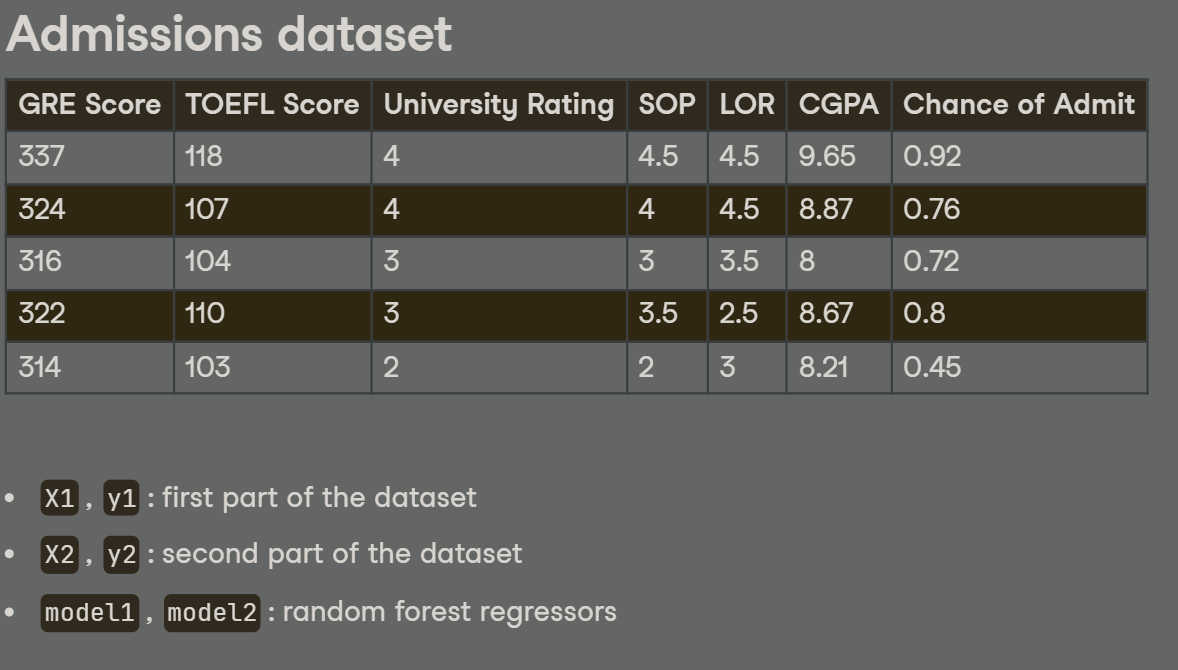

Computing consistency

In [ ]:
from Foundations of Explainable AI import feature_importances
from sklearn.metrics.pairwise import cosine_similarity
import shap
explainer1 = shap.TreeExplainer(model1)
explainer2 = shap.TreeExplainer(model2)

shap_value1 = explainer1.shap_values(X1)
shap_value2 = explainer2.shap_values(X2)

feature_importance1 = np.mean(np.abs(shap_value1), axis=0)
feature_importance2 = np.mean(np.abs(shap_value2), axis=0)

consistency = cosine_similarity([feature_importance1], [feature_importance2])
print("Consistency between SHAP values:", consistency)

### Faithfulness
- Evaluates if important features influence model's predictions
- Low faithfullness -> misleads trust in model reasoning
- Useful in sensitive applications

Computing faithfulness

In [ ]:
X_instance = X_test.iloc[[0]]
original_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Original Prediction: {original_prediction}")


In [ ]:
X_instance["GRE Score"] = 310

new_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Prediction after preturbing {importance_feature}: {new_prediction}")

faithfulness_score = np.abs(original_prediction - new_prediction)
print(f"Local Faithfulness Score: {faithfulness_score}")

### Exercise:

Evaluating SHAP explanation consistency

In [ ]:
# Calculate SHAP values and feature importance for model1
explainer1 = shap.TreeExplainer(model1)
shap_values1 = explainer1.shap_values(X1)
feature_importance1 = np.mean(np.abs(shap_values1), axis=0)

# Calculate SHAP values and feature importance for model2
explainer2 = shap.TreeExplainer(model2)
shap_values2 = explainer2.shap_values(X2)
feature_importance2 =np.mean(np.abs(shap_values2), axis=0)

# Consistency calculation
consistency = cosine_similarity([feature_importance1], [feature_importance2])
print("Consistency between SHAP values:", consistency)

Evaluating faithfulness with LIME

In [ ]:
original_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Original prediction: {original_prediction}")

# Change the gender value to 0 
X_instance['gender'] = 0

# Generate the new prediction
new_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Prediction after perturbing 'gender': {new_prediction}")

# Estimate faithfulness
faithfulness_score = np.abs(original_prediction -new_prediction )
print(f"Local Faithfulness Score: {faithfulness_score}")

### Explaining unsupervised models

#### Clustering
Group similar data points without pre-defined labels

#### Silhoutte score
- Measures clustering's quality
- Ranges from -1 to 1
    - 1 -> well-separated clusters
    - -1 -> points incorectly assigned

Feature impact on cluster quality
- Impact(f) > 0 -> Positive contribution for f
- Impact(f) < 0 -> f introduces noise

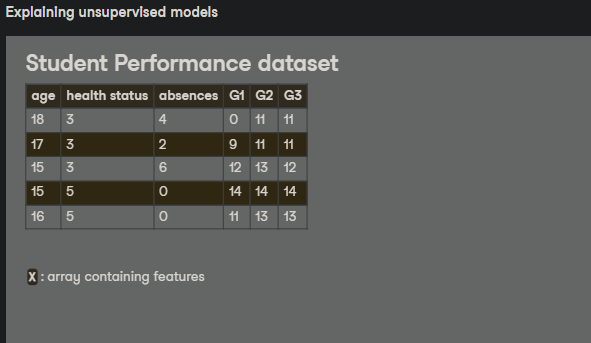

### Computing feature impact on cluster quality

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2).fit(X)
original_score = silhouette_score(X, kmeans.labels_)

for i in range(X.shape[1]):
    X_reduced = np.delete(X, i, axis=1)
    kmeans.fit(X_reduced)
    new_score = silhouette_score(X_reduced, kmeans.labels_)
    impact = original_score - new_score
    print(f"Feature {column_names[i]}: Impact = {impact}")


### ADjusted rand index (ARI)
- Measures how well cluster assigmnets match
- Maximum ARI - 1 -> Perfect cluster alignment
- Lower ARI -> greater difference in clusterings


### Feature importance for clustering assignments

- Remove faetures one at a time
- Importance(f) = 1 - ARI(original clusters, modified clusters)
- Low (ARI) -> high(1 - ARI) -> importance feature

In [ ]:
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=2).fit(X)
original_clusters = kmeans.predict(X)

for i in range(X.shape[1]):
    X_reduced = np.delete(X, i, axis=1)
    reduced_clusters = kmeans.fit(X_reduced)
    importance = 1 - adjusted_rand_score(original_clusters, reduced_clusters)
    print(f'{df.columns[i]}: {importance}')

Exercise:
- Feature impact on cluster quality

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=10, n_init=10).fit(X)
# Derive the original silhouette score
original_score = silhouette_score(X, kmeans.labels_)

for i in range(X.shape[1]):
  	# Remove feature at index i
    X_reduced = np.delete(X, i, axis=1)
    kmeans.fit(X_reduced)
    # Compute the new silhouette score
    new_score = silhouette_score(X_reduced, kmeans.labels_)
    # Compute the feature's impact
    impact = original_score - new_score
    print(f'Feature {column_names[i]}: Impact = {impact}')

- Feature importance in clustering with ARI

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=10, n_init=10).fit(X)
# Derive original clusters
original_clusters = kmeans.predict(X)

for i in range(X.shape[1]):
  	# Remove feature at index i
    X_reduced = np.delete(X, i, axis=1)
    # Derive reduced clusters
    reduced_clusters = kmeans.fit_predict(X_reduced)
    # Derive feature importance
    importance = 1 - adjusted_rand_score(original_clusters, reduced_clusters)
    print(f'{column_names[i]}: {importance}')

#### Explaining chat-based generative AI models

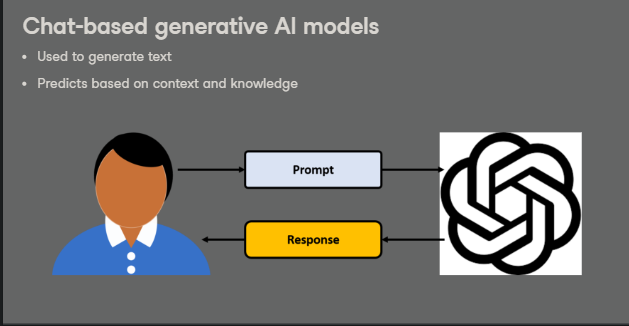

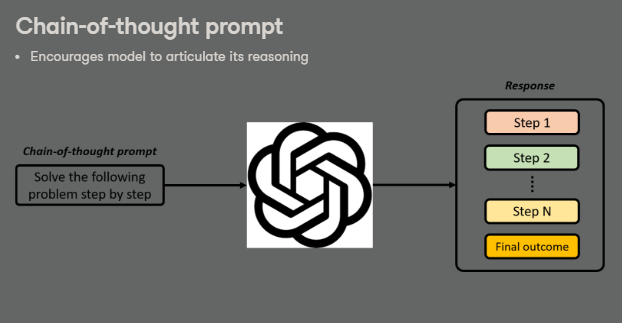

Creating a chain-of-thought prompt

In [ ]:
prompt = """A shop starts with 20 apples. It sells 5 apples and them receives 8 more. HOw many apples does the shp have now? Show your reasoning step-by-step."""
response = get_response(prompt)
print(response)

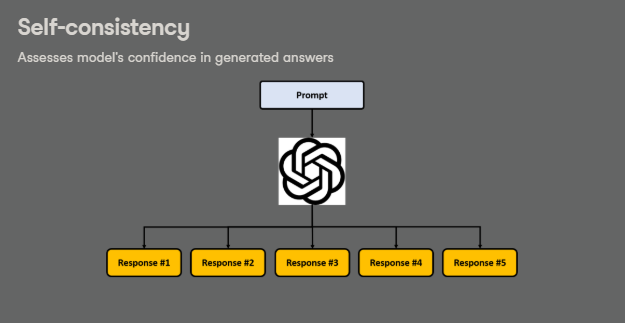

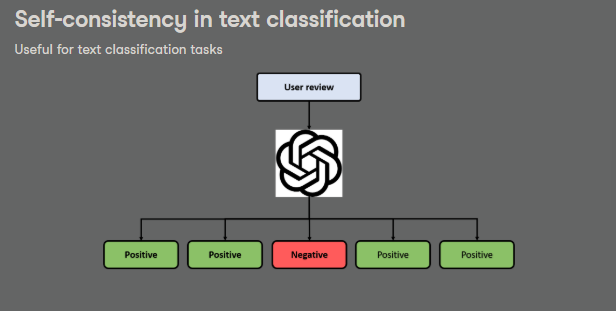

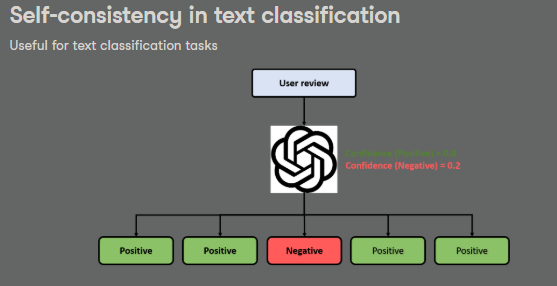

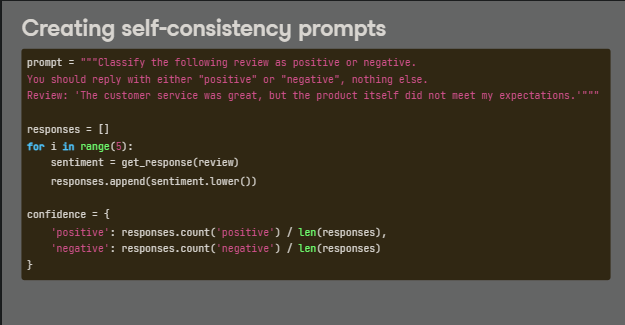

In [ ]:
responses = []
for in range(5):
    sentiment = get_response(review)
    responses.append(sentiment.lower())


confidence = {
    'postive': responses.count('positive') / len(responses),
    'negative': responses.count('negative') / len(responses)
}


print(confidence)

#### Exercise:

- Chain-of-thought to discover reasoning

In [ ]:
# Complete the chain-of-thought prompt
prompt = "In a basket, there are twice as many apples as oranges and three times as many oranges as bananas. If there are 6 bananas in the basket, how many fruits are there in total? show your flow of thought step by step"

response = get_response(prompt)
print(response)

- Self-consistency to assess confidence

In [ ]:
prompt = """Classify the following review as positive or negative. 
You should reply with either "positive" or "negative", nothing else.
Review: 'The coffee was excellent, but the service left much to be desired.'"""

responses = []
for i in range(5):
    sentiment = get_response(prompt)
    # Append the response to the responses list
    responses.append(sentiment.lower())

# Compute the confidence for each sentiment
confidence = {
    'positive': responses.count('positive') / len(responses),
    'negative': responses.count('negative') / len(responses)
}

print(confidence)